In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df  = pd.read_csv('/Users/drazenzack/Desktop/LLM_model/Model_Results/unseen_test_results.csv')
new_model = df.sort_values(by=['similarity_score'], ascending=False)

In [3]:
df2  = pd.read_csv('/Users/drazenzack/Desktop/LLM_model/Model_Results/unseen_test_results_rag.csv')
rag_model = df2.sort_values(by=['similarity_score'], ascending=False)

In [4]:
df3  = pd.read_csv('/Users/drazenzack/Desktop/LLM_model/Model_Results/unseen_test_results_rag_MultiQuery.csv')
mq_model = df3.sort_values(by=['similarity_score'], ascending=False)

In [5]:
df4  = pd.read_csv('/Users/drazenzack/Desktop/LLM_model/Model_Results/unseen_test_results_RAG_MultiQuery_update.csv')
up_model = df4.sort_values(by=['similarity_score'], ascending=False)

In [6]:
# 2 * (number of matching characters) / (total characters in both strings)
models = {
    'Rag Model': rag_model,
    'New Model': new_model,
    'Rag MQ Model': mq_model,
    'Rag MQ Updated Model': up_model
}

for model_name, model_data in models.items():
    similarity = model_data['similarity_score'].mean().round(4)
    print(f'{model_name} Similarity: {similarity}')

Rag Model Similarity: 0.8702
New Model Similarity: 0.8495
Rag MQ Model Similarity: 0.8774
Rag MQ Updated Model Similarity: 0.9053


In [9]:
num = 45

In [10]:
models = {
    'Rag Model': rag_model,
    'New Model': new_model,
    'Rag MQ Model': mq_model,
    'Rag MQ Updated Model': up_model
}

for model_name, model_data in models.items():
    test_case = model_data[model_data['test_case_id'] == num].iloc[0]
    
    print(f'\n=== {model_name} ===')
    print(test_case['instruction'])
    print('------------------')
    print(test_case['expected_output'])
    print('-----')
    print(test_case['generated_output'])


=== Rag Model ===
Sort the DataFrame by price_rt.
------------------
df.sort_values('price_rt')
-----
df.sort_values('price_rt')

=== New Model ===
Sort the DataFrame by price_rt.
------------------
df.sort_values('price_rt')
-----
df.sort_values(by='price_rt')

=== Rag MQ Model ===
Sort the DataFrame by price_rt.
------------------
df.sort_values('price_rt')
-----
df.sort_values('price_rt')

=== Rag MQ Updated Model ===
Sort the DataFrame by price_rt.
------------------
df.sort_values('price_rt')
-----
df.sort_values('price_rt')


In [11]:
for model_name, model_data in models.items():
    similarity = model_data["is_correct"].mean().round(4)
    print(f'{model_name} Is Correct: {similarity}')

Rag Model Is Correct: 0.63
New Model Is Correct: 0.6
Rag MQ Model Is Correct: 0.64
Rag MQ Updated Model Is Correct: 0.69


In [12]:
for model_name, model_data in models.items():
    meth = model_data["method_correct"].mean().round(4)
    print(f'{model_name} Method Correct: {meth}')

Rag Model Method Correct: 0.85
New Model Method Correct: 0.78
Rag MQ Model Method Correct: 0.81
Rag MQ Updated Model Method Correct: 0.86


In [13]:
for model_name, model_data in models.items():
    meth = model_data.loc[~model_data["is_correct"], "similarity_score"].mean().round(4)
    print(f'{model_name} Wrong Similarity Score: {meth}')

### When the model is wrong, how close was it to being right?'

Rag Model Wrong Similarity Score: 0.6643
New Model Wrong Similarity Score: 0.6318
Rag MQ Model Wrong Similarity Score: 0.6775
Rag MQ Updated Model Wrong Similarity Score: 0.7194


In [14]:
### When the model method is wrong, how close was it to being right?
for model_name, model_data in models.items():
    meth = model_data.loc[~model_data["method_correct"], "similarity_score"].mean().round(4)
    print(f'{model_name} Wrong Method Similarity Score: {meth}')

Rag Model Wrong Method Similarity Score: 0.4667
New Model Wrong Method Similarity Score: 0.4764
Rag MQ Model Wrong Method Similarity Score: 0.5532
Rag MQ Updated Model Wrong Method Similarity Score: 0.64


In [15]:
## Near Miss Rate: Proportion of incorrect responses with similarity score between 0.8 and 0.89
near_miss_rate_rag = (
    rag_model.loc[~rag_model["is_correct"], "similarity_score"]
    .between(0.8, 0.89)
    .mean()
)

near_miss_rate_mq = (
    mq_model.loc[~mq_model["is_correct"], "similarity_score"]
    .between(0.8, 0.89)
    .mean()
)
    

near_miss_rate = (
    new_model.loc[~new_model["is_correct"], "similarity_score"]
    .between(0.8, 0.89)
    .mean()
)

for model_name, model_data in models.items():
    near_miss_rate = (
    model_data.loc[~model_data["is_correct"], "similarity_score"]
    .between(0.8, 0.89)
    .mean()
        )
    print(f'{model_name}  Near Miss Rate: {near_miss_rate.round(4)}')

Rag Model  Near Miss Rate: 0.2432
New Model  Near Miss Rate: 0.25
Rag MQ Model  Near Miss Rate: 0.3056
Rag MQ Updated Model  Near Miss Rate: 0.1935


In [16]:
## Percentage of predictions where the model is meaningfully off-target

for model_name, model_data in models.items():
    meth = (model_data["similarity_score"] < 0.7).mean()
    print(f'{model_name} Percentage off target: {meth.round(4)}')

Rag Model Percentage off target: 0.15
New Model Percentage off target: 0.21
Rag MQ Model Percentage off target: 0.19
Rag MQ Updated Model Percentage off target: 0.14


In [17]:
# This is a task-level performance breakdown. It tells you which kinds of instructions your model struggles with vs excels at

summary = (
    pd.concat(
        {
            name: df.assign(
                task_type=df["instruction"].str.split().str[0]
            )
            .groupby("task_type")
            .agg(
                accuracy=("is_correct", "mean"),
                avg_similarity=("similarity_score", "mean"),
                count=("test_case_id", "count"),
            )
            for name, df in models.items()
        },
        names=["model"]
    )
    .sort_values(["model", "accuracy"])
)

summary.reset_index()

,model,task_type,accuracy,avg_similarity,count
0,New Model,Extract,0.000000,0.782500,8
1,New Model,Return,0.000000,0.468125,16
2,New Model,Filter,0.642857,0.870000,14
3,New Model,Compute,0.676471,0.919412,34
4,New Model,Count,1.000000,1.000000,13
5,New Model,Get,1.000000,1.000000,10
6,New Model,Sort,1.000000,0.952000,5
7,Rag MQ Model,Extract,0.250000,0.602500,8
8,Rag MQ Model,Count,0.461538,0.829231,13
9,Rag MQ Model,Filter,0.500000,0.852857,14


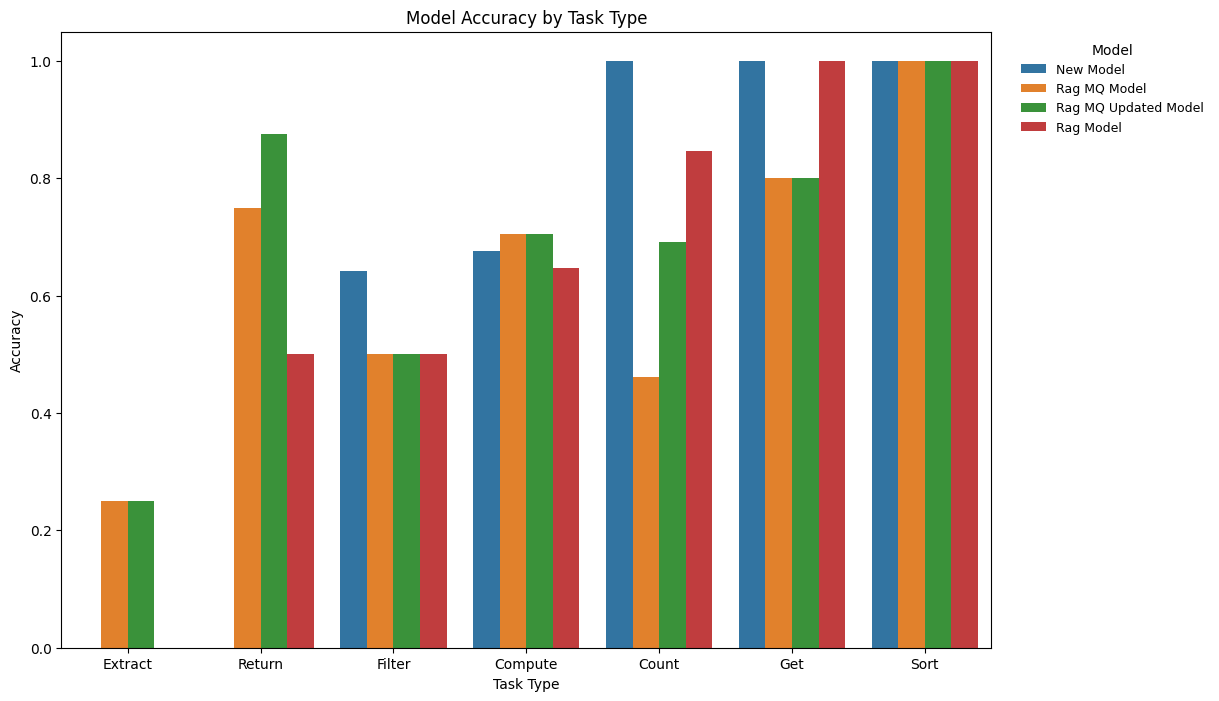

In [18]:
plt.figure(figsize=(12, 8))
sns.barplot(
    data=summary.reset_index(),
    x="task_type",
    y="accuracy",
    hue="model"
)
plt.title("Model Accuracy by Task Type")
plt.ylabel("Accuracy")
plt.xlabel("Task Type")
# Legend outside + smaller
plt.legend(
    title="Model",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=9,
    title_fontsize=10,
    frameon=False
)
plt.show()

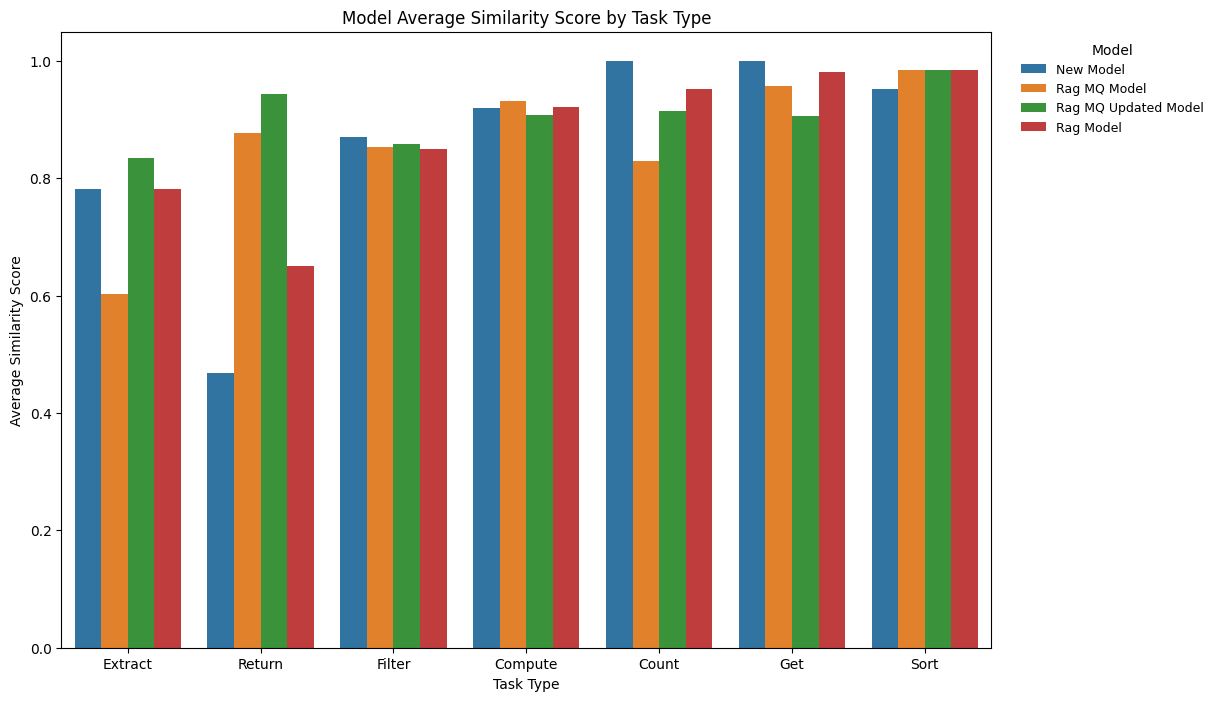

In [19]:
plt.figure(figsize=(12, 8))
sns.barplot(
    data=summary.reset_index(),
    x="task_type",
    y="avg_similarity",
    hue="model"
)
plt.title("Model Average Similarity Score by Task Type")
plt.ylabel("Average Similarity Score")
plt.xlabel("Task Type")
# Legend outside + smaller
plt.legend(
    title="Model",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=9,
    title_fontsize=10,
    frameon=False
)
plt.show()

In [20]:
# This line creates a weighted, holistic model score that:
# 	•	values being right
# 	•	values using the right method
# 	•	values being close when wrong

for model_name, model_data in models.items():
    final_score = (
    0.3 * model_data["is_correct"].mean() +
    0.4 * model_data["method_correct"].mean() +
    0.3 * model_data["similarity_score"].mean())       
    print(f'{model_name} Final Score: {final_score.round(4)}')

Rag Model Final Score: 0.7901
New Model Final Score: 0.7468
Rag MQ Model Final Score: 0.7792
Rag MQ Updated Model Final Score: 0.8226


In [21]:
cols = ["test_case_id", "is_correct", "similarity_score", "method_correct"]

new2 = new_model[cols].sort_values("test_case_id").reset_index(drop=True)
base2 = rag_model[cols].sort_values("test_case_id").reset_index(drop=True)
mq2 = mq_model[cols].sort_values("test_case_id").reset_index(drop=True)
up2 = up_model[cols].sort_values("test_case_id").reset_index(drop=True)

assert (new2["test_case_id"] == base2["test_case_id"]).all()

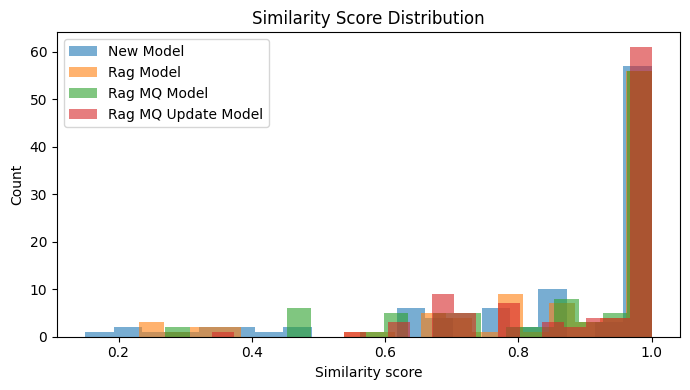

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.hist(new2["similarity_score"], bins=20, alpha=0.6, label="New Model")
plt.hist(base2["similarity_score"], bins=20, alpha=0.6, label="Rag Model")
plt.hist(mq2["similarity_score"], bins=20, alpha=0.6, label="Rag MQ Model")
plt.hist(up2["similarity_score"], bins=20, alpha=0.6, label="Rag MQ Update Model")
plt.xlabel("Similarity score")
plt.ylabel("Count")
plt.legend()
plt.title("Similarity Score Distribution")
plt.tight_layout()
plt.show()

In [23]:
# a_only = ((new2.method_correct) & (~base2.method_correct)).sum()
# b_only = ((~new2.method_correct) & (base2.method_correct)).sum()
# both = ((new2.method_correct) & (base2.method_correct)).sum()
# neither = ((~new2.method_correct) & (~base2.method_correct)).sum()

# plt.figure(figsize=(10,4))
# plt.bar(
#     ["New Model only correct", "Rag Model only correct", "Both correct", "Both wrong"],
#     [a_only, b_only, both, neither]
# )
# plt.ylabel("Count")
# plt.title("Accuracy Agreement Breakdown (Method Correct)")
# plt.tight_layout()
# plt.show()

/var/folders/tt/5g7kjc2j66b3f51x1pj2tcqh0000gn/T/ipykernel_37013/4010316469.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([err_new, err_base, err_mq, err_up], labels=["New Model", "Rag Model", "Rag MQ Model", "Rag MQ Update Model"])


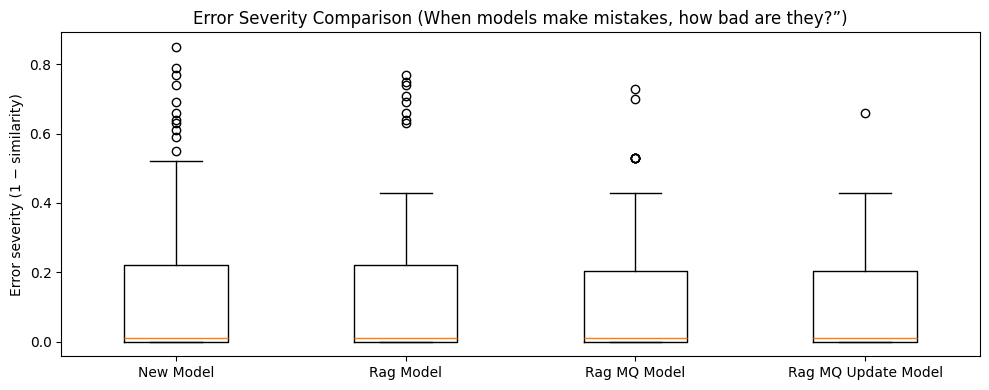

In [24]:
err_new = 1 - new2["similarity_score"]
err_base = 1 - base2["similarity_score"]
err_mq = 1 - mq2["similarity_score"]
err_up = 1 - up2["similarity_score"]

plt.figure(figsize=(10,4))
plt.boxplot([err_new, err_base, err_mq, err_up], labels=["New Model", "Rag Model", "Rag MQ Model", "Rag MQ Update Model"])
plt.ylabel("Error severity (1 − similarity)")
plt.title("Error Severity Comparison (When models make mistakes, how bad are they?”)")
plt.tight_layout()
plt.show()

In [25]:
# plt.figure(figsize=(10,4))
# plt.hist(diff, bins=30)
# plt.axvline(0, linestyle="--")
# plt.axvline(diff.mean())
# plt.title("Model New vs RAG — Per-Case Quality Difference")
# plt.xlabel("Similarity difference (New − RAG)")
# plt.tight_layout()
# plt.show()

In [26]:
new_model["task_type"] = (
    new_model["instruction"]
    .str.lower()
    .str.split().str[0]
    .fillna("other")
)

rag_model["task_type"] = (
    rag_model["instruction"]
    .str.lower()
    .str.split().str[0]
    .fillna("other")
)

mq_model["task_type"] = (
    mq_model["instruction"]
    .str.lower()
    .str.split().str[0]
    .fillna("other")
)

up_model["task_type"] = (
    up_model["instruction"]
    .str.lower()
    .str.split().str[0]
    .fillna("other")
)

In [27]:
task_stats_new = (
    new_model.groupby("task_type")
      .agg(
          accuracy=("is_correct", "mean"),
          avg_similarity=("similarity_score", "mean"),
          error_rate=("is_correct", lambda x: 1 - x.mean()),
          avg_error_severity=("similarity_score", lambda x: (1 - x).mean()),
          count=("test_case_id", "count")
      )
)

task_stats_new

,accuracy,avg_similarity,error_rate,avg_error_severity,count
task_type,,,,,
compute,0.676471,0.919412,0.323529,0.080588,34
count,1.000000,1.000000,0.000000,0.000000,13
extract,0.000000,0.782500,1.000000,0.217500,8
filter,0.642857,0.870000,0.357143,0.130000,14
get,1.000000,1.000000,0.000000,0.000000,10
return,0.000000,0.468125,1.000000,0.531875,16
sort,1.000000,0.952000,0.000000,0.048000,5


In [28]:
task_stats_base = (
rag_model.groupby("task_type")
      .agg(
          accuracy=("is_correct", "mean"),
          avg_similarity=("similarity_score", "mean"),
          error_rate=("is_correct", lambda x: 1 - x.mean()),
          avg_error_severity=("similarity_score", lambda x: (1 - x).mean()),
          count=("test_case_id", "count")
      )
)

task_stats_base

,accuracy,avg_similarity,error_rate,avg_error_severity,count
task_type,,,,,
compute,0.647059,0.922059,0.352941,0.077941,34
count,0.846154,0.951538,0.153846,0.048462,13
extract,0.000000,0.782500,1.000000,0.217500,8
filter,0.500000,0.849286,0.500000,0.150714,14
get,1.000000,0.982000,0.000000,0.018000,10
return,0.500000,0.650625,0.500000,0.349375,16
sort,1.000000,0.984000,0.000000,0.016000,5


In [29]:
task_stats_mq = (
mq_model.groupby("task_type")
      .agg(
          accuracy=("is_correct", "mean"),
          avg_similarity=("similarity_score", "mean"),
          error_rate=("is_correct", lambda x: 1 - x.mean()),
          avg_error_severity=("similarity_score", lambda x: (1 - x).mean()),
          count=("test_case_id", "count")
      )
)

task_stats_mq

,accuracy,avg_similarity,error_rate,avg_error_severity,count
task_type,,,,,
compute,0.705882,0.931176,0.294118,0.068824,34
count,0.461538,0.829231,0.538462,0.170769,13
extract,0.250000,0.602500,0.750000,0.397500,8
filter,0.500000,0.852857,0.500000,0.147143,14
get,0.800000,0.958000,0.200000,0.042000,10
return,0.750000,0.877500,0.250000,0.122500,16
sort,1.000000,0.984000,0.000000,0.016000,5


In [30]:
task_stats_up = (
up_model.groupby("task_type")
      .agg(
          accuracy=("is_correct", "mean"),
          avg_similarity=("similarity_score", "mean"),
          error_rate=("is_correct", lambda x: 1 - x.mean()),
          avg_error_severity=("similarity_score", lambda x: (1 - x).mean()),
          count=("test_case_id", "count")
      )
)

task_stats_up

,accuracy,avg_similarity,error_rate,avg_error_severity,count
task_type,,,,,
compute,0.705882,0.907941,0.294118,0.092059,34
count,0.692308,0.914615,0.307692,0.085385,13
extract,0.250000,0.835000,0.750000,0.165000,8
filter,0.500000,0.858571,0.500000,0.141429,14
get,0.800000,0.906000,0.200000,0.094000,10
return,0.875000,0.943125,0.125000,0.056875,16
sort,1.000000,0.984000,0.000000,0.016000,5


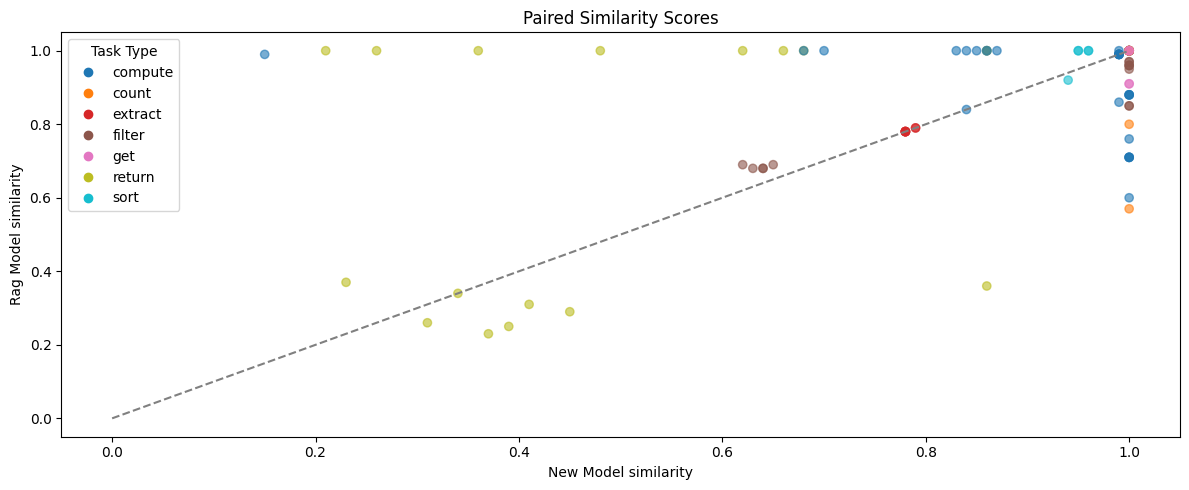

In [31]:
new_model2 = new_model.sort_values('test_case_id').reset_index(drop=True)
base_model2 = rag_model.sort_values('test_case_id').reset_index(drop=True)
mq_model2 = mq_model.sort_values('test_case_id').reset_index(drop=True)
up_model2 = up_model.sort_values('test_case_id').reset_index(drop=True)
plt.figure(figsize=(12,5))

# Encode task_type as categories
cats = new_model2['task_type'].astype('category')
codes = cats.cat.codes
labels = cats.cat.categories

# Scatter
scatter = plt.scatter(
    x=new_model2["similarity_score"],
    y=base_model2["similarity_score"],
    c=codes,
    alpha=0.6,
    cmap="tab10"
)

# Identity line
plt.plot([0,1], [0,1], linestyle="--", color="gray")

# Build legend manually
handles = [
    plt.Line2D(
        [0], [0],
        marker='o',
        linestyle='',
        color=scatter.cmap(scatter.norm(i)),
        label=label
    )
    for i, label in enumerate(labels)
]

plt.legend(handles=handles, title="Task Type")

plt.xlabel("New Model similarity")
plt.ylabel("Rag Model similarity")
plt.title("Paired Similarity Scores")

plt.tight_layout()
plt.show()

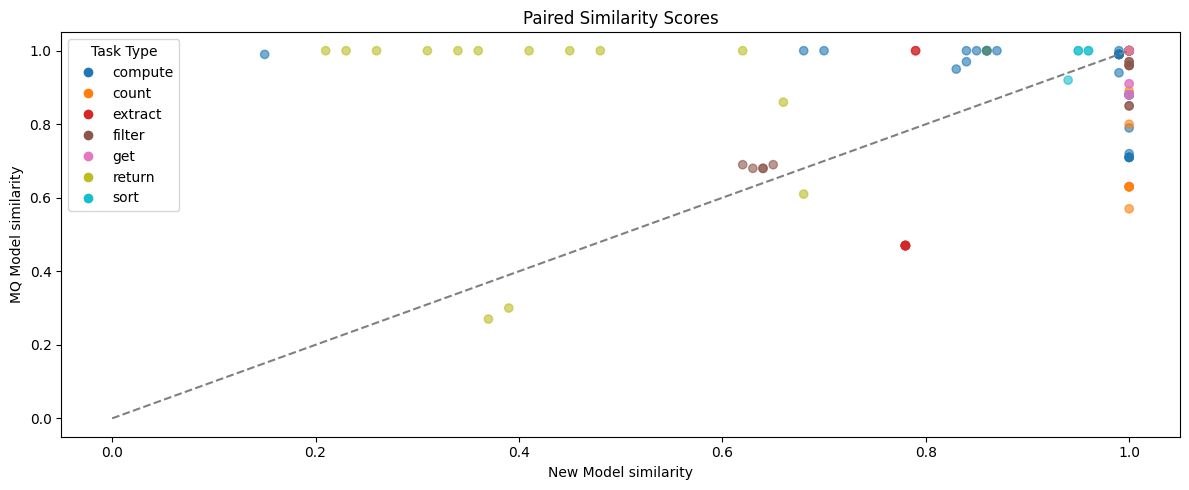

In [32]:
plt.figure(figsize=(12,5))

# Encode task_type as categories
cats = new_model2['task_type'].astype('category')
codes = cats.cat.codes
labels = cats.cat.categories

# Scatter
scatter = plt.scatter(
    x=new_model2["similarity_score"],
    y=mq_model2["similarity_score"],
    c=codes,
    alpha=0.6,
    cmap="tab10"
)

# Identity line
plt.plot([0,1], [0,1], linestyle="--", color="gray")

# Build legend manually
handles = [
    plt.Line2D(
        [0], [0],
        marker='o',
        linestyle='',
        color=scatter.cmap(scatter.norm(i)),
        label=label
    )
    for i, label in enumerate(labels)
]

plt.legend(handles=handles, title="Task Type")

plt.xlabel("New Model similarity")
plt.ylabel("MQ Model similarity")
plt.title("Paired Similarity Scores")

plt.tight_layout()
plt.show()

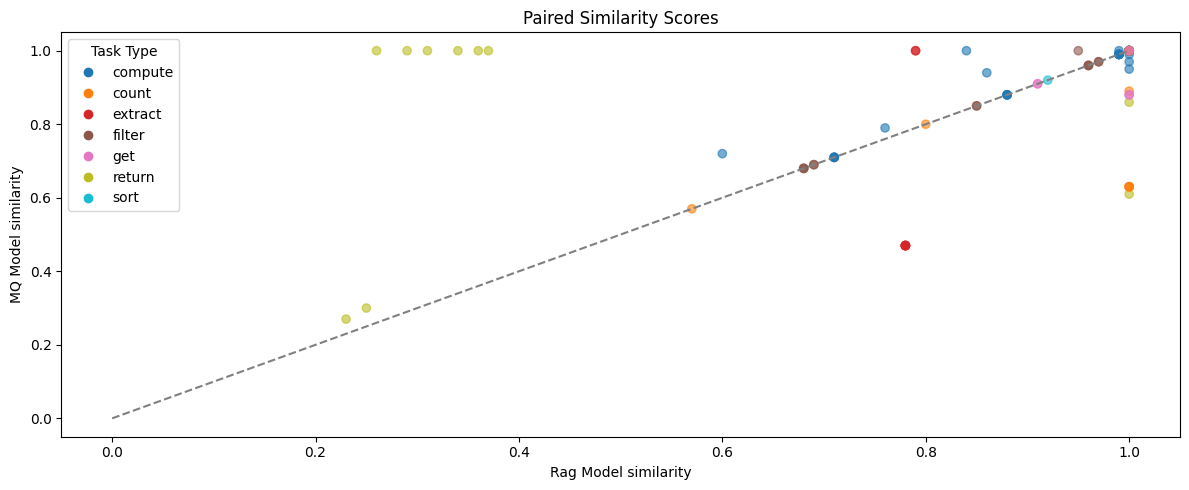

In [33]:
plt.figure(figsize=(12,5))

# Encode task_type as categories
cats = base_model2['task_type'].astype('category')
codes = cats.cat.codes
labels = cats.cat.categories

# Scatter
scatter = plt.scatter(
    x=base_model2["similarity_score"],
    y=mq_model2["similarity_score"],
    c=codes,
    alpha=0.6,
    cmap="tab10"
)

# Identity line
plt.plot([0,1], [0,1], linestyle="--", color="gray")

# Build legend manually
handles = [
    plt.Line2D(
        [0], [0],
        marker='o',
        linestyle='',
        color=scatter.cmap(scatter.norm(i)),
        label=label
    )
    for i, label in enumerate(labels)
]

plt.legend(handles=handles, title="Task Type")

plt.xlabel("Rag Model similarity")
plt.ylabel("MQ Model similarity")
plt.title("Paired Similarity Scores")

plt.tight_layout()
plt.show()

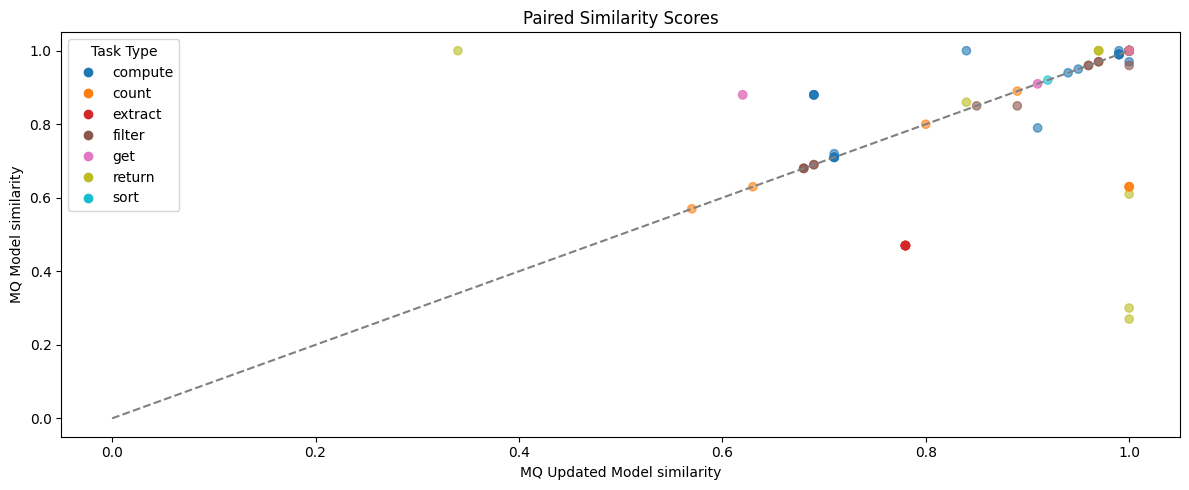

In [34]:
plt.figure(figsize=(12,5))

# Encode task_type as categories
cats = up_model2['task_type'].astype('category')
codes = cats.cat.codes
labels = cats.cat.categories

# Scatter
scatter = plt.scatter(
    x=up_model2["similarity_score"],
    y=mq_model2["similarity_score"],
    c=codes,
    alpha=0.6,
    cmap="tab10"
)

# Identity line
plt.plot([0,1], [0,1], linestyle="--", color="gray")

# Build legend manually
handles = [
    plt.Line2D(
        [0], [0],
        marker='o',
        linestyle='',
        color=scatter.cmap(scatter.norm(i)),
        label=label
    )
    for i, label in enumerate(labels)
]

plt.legend(handles=handles, title="Task Type")

plt.xlabel("MQ Updated Model similarity")
plt.ylabel("MQ Model similarity")
plt.title("Paired Similarity Scores")

plt.tight_layout()
plt.show()

In [35]:
up_model[up_model['task_type'] == "count"]

,test_case_id,instruction,expected_output,generated_output,similarity_score,is_correct,method_correct,error,task_type
0,1,Count unique values of price_rt.,df['price_rt'].nunique(),df['price_rt'].nunique(),1.00,True,True,NaN,count
49,50,Count unique values of price_da.,df['price_da'].nunique(),df['price_da'].nunique(),1.00,True,True,NaN,count
55,56,Count unique values of load_fcst.,df['load_fcst'].nunique(),df['load_fcst'].nunique(),1.00,True,True,NaN,count
68,69,Count unique values of price_rt.,df['price_rt'].nunique(),df['price_rt'].nunique(),1.00,True,True,NaN,count
92,93,Count unique values of load_fcst.,df['load_fcst'].nunique(),df['load_fcst'].nunique(),1.00,True,True,NaN,count
95,96,Count unique values of price_rt.,df['price_rt'].nunique(),df['price_rt'].nunique(),1.00,True,True,NaN,count
17,18,Count unique values of price_rt.,df['price_rt'].nunique(),df['price_rt'].nunique(),1.00,True,True,NaN,count
9,10,Count unique values of load_fcst.,df['load_fcst'].nunique(),df['load_fcst'].nunique(),1.00,True,True,NaN,count
2,3,Count unique values of predicted_err.,df['predicted_err'].nunique(),df['predicted_err'].nunique(),1.00,True,True,NaN,count
37,38,Count unique values of predicted.,df['predicted'].nunique(),df['pred'].nunique(),0.89,False,True,NaN,count


In [36]:
up_model[up_model['task_type'] == "get"]

,test_case_id,instruction,expected_output,generated_output,similarity_score,is_correct,method_correct,error,task_type
48,49,Get unique values of wind_fcst_v2.,df['wind_fcst_v2'].unique(),df['wind_fcst_v2'].unique(),1.00,True,True,NaN,get
33,34,Get unique values of load_fcst.,df['load_fcst'].unique(),df['load_fcst'].unique(),1.00,True,True,NaN,get
89,90,Get unique values of wind_fcst.,df['wind_fcst'].unique(),df['wind_fcst'].unique(),1.00,True,True,NaN,get
97,98,Get unique values of total_delta.,df['total_delta'].unique(),df['total_delta'].unique(),1.00,True,True,NaN,get
12,13,Get unique values of predicted_scaled.,df['predicted_scaled'].unique(),df['predicted_scaled'].unique(),1.00,True,True,NaN,get
26,27,Get unique values of predicted_scaled.,df['predicted_scaled'].unique(),df['predicted_scaled'].unique(),1.00,True,True,NaN,get
88,89,Get unique values of power.,df['power'].unique(),df['power_OBS'].unique(),0.91,True,True,NaN,get
35,36,Get unique values of power.,df['power'].unique(),df['power_OBS'].unique(),0.91,True,True,NaN,get
86,87,Get unique values of predicted.,df['predicted'].unique(),"df[['predicted']].apply(lambda x: x.unique(), ...",0.62,False,False,NaN,get
98,99,Get unique values of predicted.,df['predicted'].unique(),"df[['predicted']].apply(lambda x: x.unique(), ...",0.62,False,False,NaN,get
